# 03 — Results analysis

Reads all per-run CSVs from `output/results/03_train_models/` and summarises model performance.

In [1]:
import glob
import os
import stylia

stylia.set_style("ersilia")
nc = stylia.NamedColors()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 300
plt.rcParams["xtick.minor.pad"] = 1  # default is 3.5
plt.rcParams["hatch.linewidth"] = 0.4  # previous pdf hatch linewidth

RESULTS_DIR = "../results/chembl"

In [2]:
# Load and concatenate all run CSVs
files = sorted(glob.glob(os.path.join(RESULTS_DIR, "*.csv")))
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(f"{len(files)} run files → {len(df)} rows")

# Map pathogen codes to full names
pathogens = pd.read_csv(
    "/home/acomajuncosa/github/chembl-antimicrobial-models/config/pathogens.csv"
)
pathogen_codes = dict(zip(pathogens["code"], pathogens["pathogen"]))

# Add compound / active counts from selected-datasets metadata
_meta = pd.read_csv(
    "/home/acomajuncosa/github/chembl-antimicrobial-models/data/processed/01b_selected_datasets.csv"
)[["pathogen", "name", "compounds", "positives"]]
df = df.merge(
    _meta, left_on=["pathogen", "dataset"], right_on=["pathogen", "name"], how="left"
).drop(columns="name")
cols = [i for i in df.columns if i not in ["compounds", "positives"]]
cols = cols[:3] + ["compounds", "positives"] + cols[3:]
df = df[cols]

# Show only performance
cols = [i for i in df.columns if "time" not in i and "onnx" not in i]
df[cols]

2 run files → 2 rows


,pathogen,dataset,mode,compounds,positives,n_train,n_test,n_pos_train,n_neg_train,n_pos_test,n_neg_test,auroc_lazy,aupr_lazy,bedroc_lazy,aupr_baseline,sensitivity,specificity,auroc_rf,aupr_rf,bedroc_rf,auroc_lr,aupr_lr,bedroc_lr,auroc_xgb,aupr_xgb,bedroc_xgb,auroc_svc,aupr_svc,bedroc_svc,head_score_cddd_lr,head_score_cddd_xgb,head_score_cddd_rf,head_score_cddd_svc,pooler_cddd_mode,pooler_cddd_score,head_score_chemeleon_lr,head_score_chemeleon_xgb,head_score_chemeleon_rf,head_score_chemeleon_svc,pooler_chemeleon_mode,pooler_chemeleon_score,head_score_clamp_lr,head_score_clamp_xgb,head_score_clamp_rf,head_score_clamp_svc,pooler_clamp_mode,pooler_clamp_score,head_score_morgan_lr,head_score_morgan_xgb,head_score_morgan_rf,head_score_morgan_svc,pooler_morgan_mode,pooler_morgan_score,head_score_rdkit_lr,head_score_rdkit_xgb,head_score_rdkit_rf,head_score_rdkit_svc,pooler_rdkit_mode,pooler_rdkit_score,brier_score,brier_baseline,ece,prob_active_min,prob_active_p5,prob_active_p25,prob_active_p50,prob_active_p75,prob_active_p95,prob_active_max,prob_inactive_min,prob_inactive_p5,prob_inactive_p25,prob_inactive_p50,prob_inactive_p75,prob_inactive_p95,prob_inactive_max,optimal_cutoff,calibration_y,calibration_frac,score_active_min,score_active_p5,score_active_p25,score_active_p50,score_active_p75,score_active_p95,score_active_max,score_inactive_min,score_inactive_p5,score_inactive_p25,score_inactive_p50,score_inactive_p75,score_inactive_p95,score_inactive_max,rank_active_min,rank_active_p5,rank_active_p25,rank_active_p50,rank_active_p75,rank_active_p95,rank_active_max,rank_inactive_min,rank_inactive_p5,rank_inactive_p25,rank_inactive_p50,rank_inactive_p75,rank_inactive_p95,rank_inactive_max,lift_active_min,lift_active_p5,lift_active_p25,lift_active_p50,lift_active_p75,lift_active_p95,lift_active_max,lift_inactive_min,lift_inactive_p5,lift_inactive_p25,lift_inactive_p50,lift_inactive_p75,lift_inactive_p95,lift_inactive_max,logit_active_min,logit_active_p5,logit_active_p25,logit_active_p50,logit_active_p75,logit_active_p95,logit_active_max,logit_inactive_min,logit_inactive_p5,logit_inactive_p25,logit_inactive_p50,logit_inactive_p75,logit_inactive_p95,logit_inactive_max,ef_1pct,recall_at_1pct,ef_2pct,recall_at_2pct,ef_5pct,recall_at_5pct,ef_10pct,recall_at_10pct,ef_20pct,recall_at_20pct,decision_cutoff_raw,decision_cutoff_proba,decision_cutoff_rank,decision_cutoff_logit,decision_cutoff_lift,roc_y_rf,pr_y_rf,enrichment_y_rf,roc_y_lr,pr_y_lr,enrichment_y_lr,roc_y_xgb,pr_y_xgb,enrichment_y_xgb,roc_y_svc,pr_y_svc,enrichment_y_svc,roc_y_lazy,pr_y_lazy,enrichment_y_lazy
0,calbicans,G_ORG7_10.0,fast,867,135,693,174,108,585,27,147,0.9123,0.7752,0.8599,0.1552,0.8889,0.8639,0.9204,0.7667,0.8602,0.8502,0.6434,0.7852,0.9242,0.7764,0.8545,0.8776,0.7649,0.8847,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.6999,0.7501,0.7535,0.6913,equal,0.7764,NaN,NaN,NaN,NaN,NaN,NaN,0.0693,0.1311,0.0723,0.0609,0.0783,0.3076,0.5899,0.7247,0.7575,0.7635,0.0588,0.0608,0.0641,0.0686,0.0887,0.3774,0.6762,0.1749,0.0174;0.1053;0.3000;0.4000;0.3333;0.8000;0.50...,0.6609;0.1092;0.0575;0.0287;0.0172;0.0287;0.04...,0.0554,0.1038,0.4647,0.7727,0.8988,0.9419,0.9461,0.0503,0.0609,0.0708,0.0811,0.1301,0.5465,0.8582,0.1994,0.5791,0.8558,0.9134,0.9716,0.9864,0.9921,0.0947,0.1286,0.2657,0.4364,0.6554,0.8741,0.9427,0.3907,0.5022,1.9740,3.7853,4.6502,4.8609,4.8994,0.3776,0.3901,0.4114,0.4400,0.5694,2.4215,4.3390,-2.7360,-2.4816,-0.8116,0.3636,0.9683,1.1393,1.1722,-2.7721,-2.7376,-2.6808,-2.6088,-2.3293,-0.5009,0.7364,6.4444,0.0741,6.4444,0.1111,6.4444,0.3333,4.9281,0.4815,4.0508,0.8148,0.174897,0.106124,0.742775,-2.130956,0.680964,0.3704;0.4052;0.4967;0.5881;0.7407;0.7407;0.75...,1.0000;1.0000;1.0000;1.0000;1.0000;1.0000;1.00...,0.0644;0.1289;0.1933;0.2578;0.3222;0.3704;0.37...,0.2593;0.3659;0.4074;0.4444;0.5315;0.5556;0.56...,1.0000;1.0000;1.0000;1.0000;1.0000;1.0000;1.00...,0.0644;0.1289;0.1933;0.2578;0.2593;0.2963;0.34...,0.3704;0.4815;0.6296;0.6296;0.6667;0.70

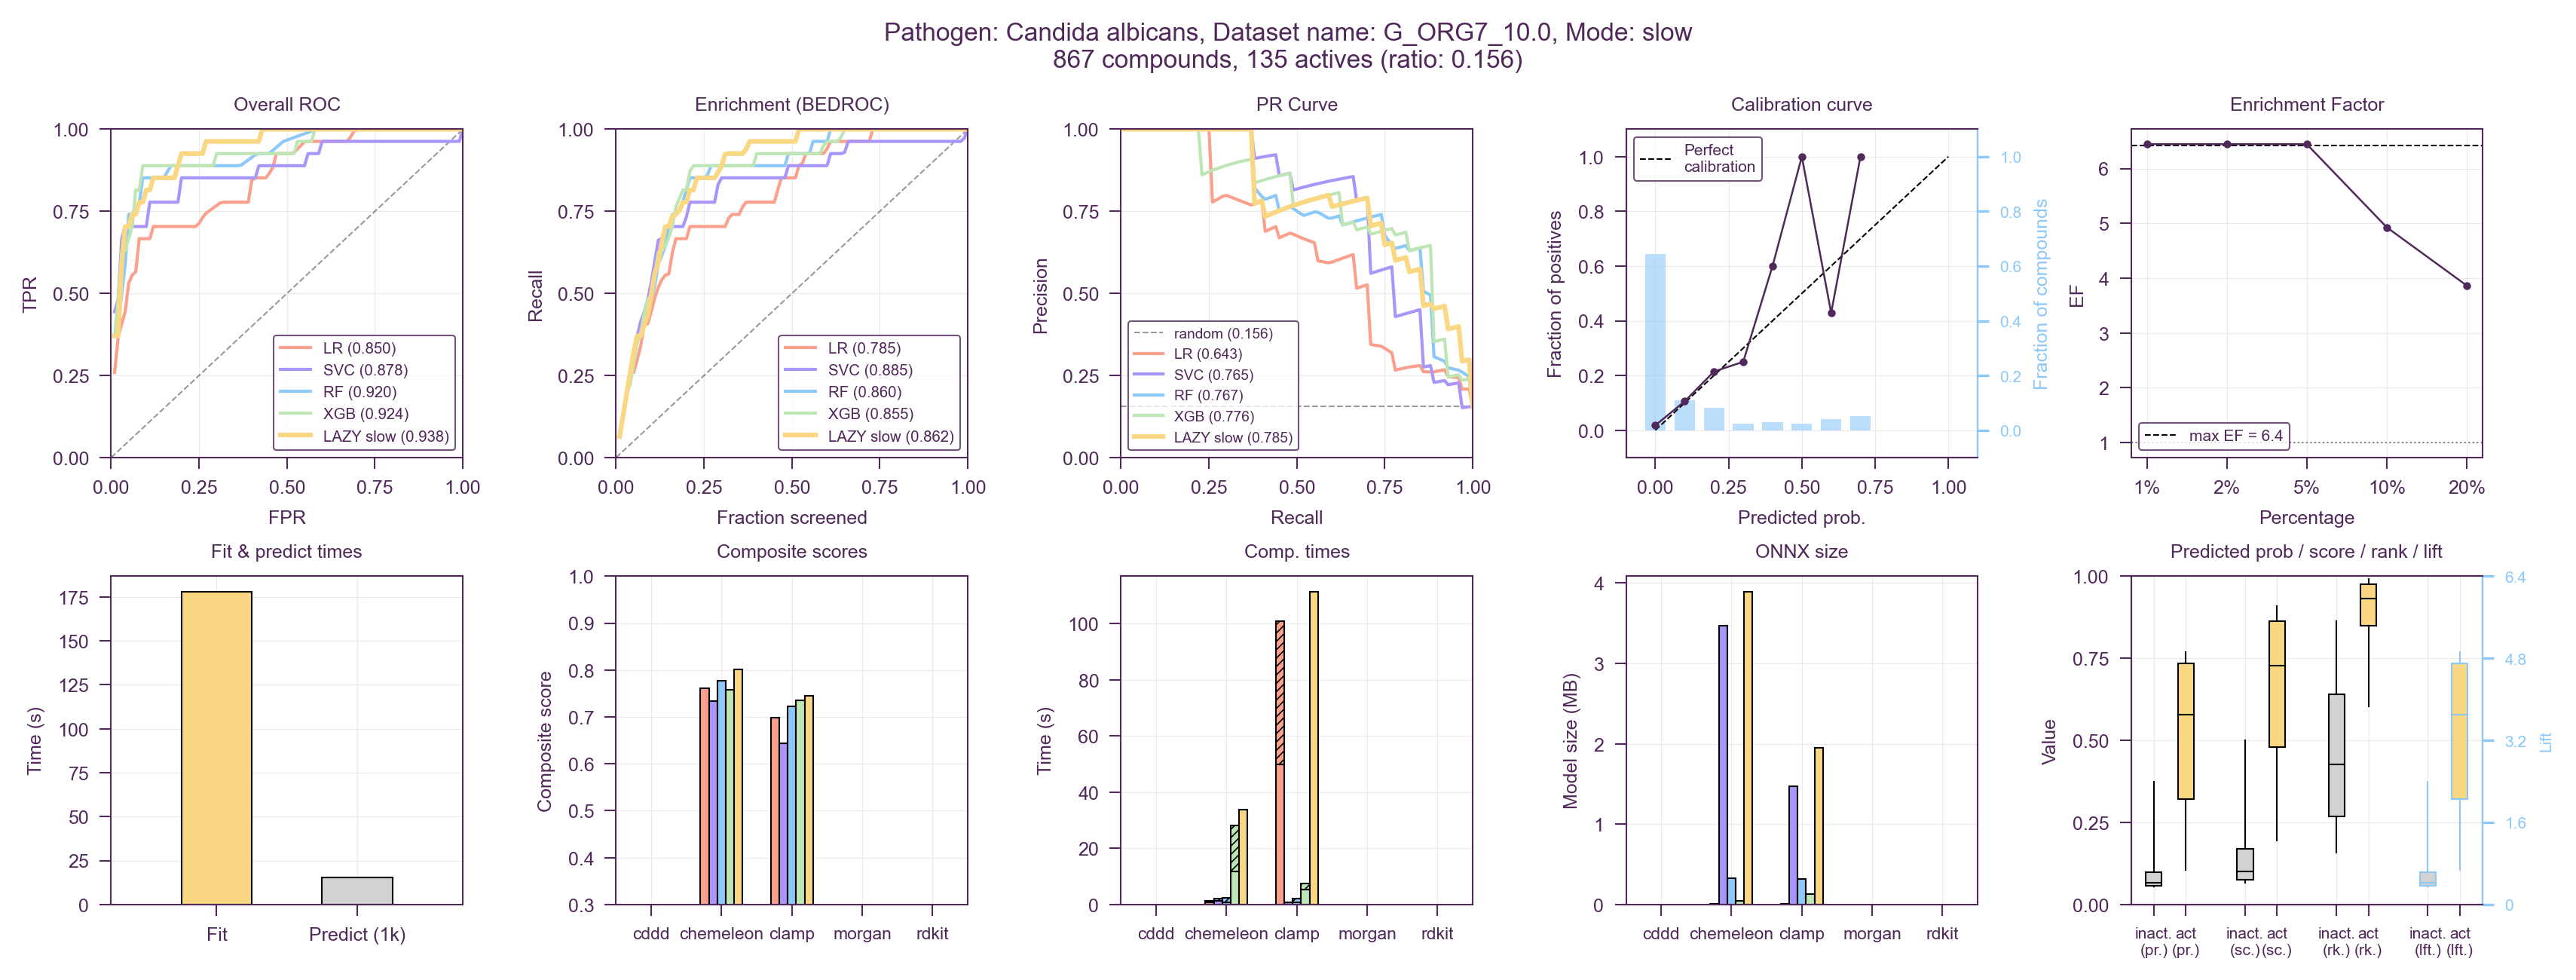

In [111]:
DATASETS = [
    ["calbicans", "G_ORG7_10.0"],
    ["ecoli", "G_ORG7_10.0"],
    ["paeruginosa", "G_ORG5_50.0"],
    ["smansoni", "G_ORG1_10.0"],
    ["abaumannii", "G_ORG0_10.0"],
    ["calbicans", "G_ORG0_50.0"],
    ["saureus", "G_ORG6_10.0"],
    ["mtuberculosis", "G_ORG1_10.0"],
    ["ecoli", "G_ORG2_10.0"],
    ["pfalciparum", "CHEMBL1054501_INHIBITION_%_qt_75.0"],
    ["pfalciparum", "CHEMBL4888485_INHIBITION_%_qt_50.0"],
]

HEADS_ORDERED = ["lr", "svc", "rf", "xgb"]
HEAD_COLORS = {"lr": nc.orange, "rf": nc.blue, "xgb": nc.mint, "svc": nc.purple}
mode = "slow"
modes = ["slow"]


def _get(row, col):
    v = row.get(col, np.nan)
    return np.nan if (v is None or (isinstance(v, float) and np.isnan(v))) else float(v)


for pathogen, dataset in DATASETS:
    df_subset = df[(df["pathogen"] == pathogen) & (df["dataset"] == dataset)]
    colors_map = {"fast": nc.blue, "slow": nc.mint}

    stylia.set_format("print")

    def _parse_curve(s):
        if not isinstance(s, str):
            return None
        return np.array([float(v) if v != "nan" else np.nan for v in s.split(";")])

    fig, axs = stylia.create_figure(2, 5, width=1.6, height=0.6)
    actives = df_subset["positives"].values[0]
    compounds = df_subset["compounds"].values[0]

    ################################################
    ######### ROW 1: SUMMARIES #####################
    ################################################

    # [0] Overall ROC curve
    ax = axs.next()
    ax.set_title("Overall ROC")
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
    ax.plot([0, 1], [0, 1], color="k", lw=0.5, ls="--", alpha=0.4)
    _roc_x = np.linspace(0.01, 1, 100)
    baseline_curve_cols = {
        "LR": "roc_y_lr",
        "SVC": "roc_y_svc",
        "RF": "roc_y_rf",
        "XGB": "roc_y_xgb",
    }
    baseline_colors = {"LR": nc.orange, "RF": nc.blue, "XGB": nc.mint, "SVC": nc.purple}
    df_slow = df_subset[df_subset["mode"] == "slow"]
    for lbl, col in baseline_curve_cols.items():
        if col not in df_slow.columns or len(df_slow) == 0:
            continue
        y = _parse_curve(df_slow.iloc[0][col])
        if y is not None:
            auc = df_slow.iloc[0][col.replace("roc_y_", "auroc_")]
            ax.plot(
                _roc_x, y, color=baseline_colors[lbl], lw=1, label=f"{lbl} ({auc:.3f})"
            )
    for j, mode in enumerate(modes):
        df_mode = df_subset[df_subset["mode"] == mode]
        if len(df_mode) == 0:
            continue
        y = _parse_curve(df_mode.iloc[0]["roc_y_lazy"])
        if y is not None:
            auc = df_mode.iloc[0]["auroc_lazy"]
            ax.plot(
                _roc_x,
                y,
                color=nc.yellow,
                lw=1.5,
                ls=["-", "--"][j % 2],
                label=f"LAZY {mode} ({auc:.3f})",
            )
    leg = ax.legend(prop={"size": 4.9}, loc="lower right")
    frame = leg.get_frame()
    frame.set_edgecolor(nc.plum)
    frame.set_linewidth(0.5)

    # [1] Enrichment curve (BEDROC)
    ax = axs.next()
    ax.set_title("Enrichment (BEDROC)")
    ax.set_xlabel("Fraction screened")
    ax.set_ylabel("Recall")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
    # Random baseline: recover actives proportional to fraction screened
    ax.plot([0, 1], [0, 1], color="k", lw=0.5, ls="--", alpha=0.4)
    baseline_curve_cols = {
        "LR": "enrichment_y_lr",
        "SVC": "enrichment_y_svc",
        "RF": "enrichment_y_rf",
        "XGB": "enrichment_y_xgb",
    }
    for lbl, col in baseline_curve_cols.items():
        if col not in df_slow.columns or len(df_slow) == 0:
            continue
        y = _parse_curve(df_slow.iloc[0][col])
        if y is not None:
            bedroc = df_slow.iloc[0][col.replace("enrichment_y_", "bedroc_")]
            ax.plot(
                _roc_x,
                y,
                color=baseline_colors[lbl],
                lw=1,
                label=f"{lbl} ({bedroc:.3f})",
            )
    for j, mode in enumerate(modes):
        df_mode = df_subset[df_subset["mode"] == mode]
        if len(df_mode) == 0:
            continue
        y = _parse_curve(df_mode.iloc[0]["enrichment_y_lazy"])
        if y is not None:
            bedroc = df_mode.iloc[0]["bedroc_lazy"]
            ax.plot(
                _roc_x,
                y,
                color=nc.yellow,
                lw=1.5,
                ls=["-", "--"][j % 2],
                label=f"LAZY {mode} ({bedroc:.3f})",
            )
    leg = ax.legend(prop={"size": 4.9}, loc="lower right")
    frame = leg.get_frame()
    frame.set_edgecolor(nc.plum)
    frame.set_linewidth(0.5)

    # [2] PR Curve
    ax = axs.next()
    ax.set_title("PR Curve")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1])
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1])

    # Random baseline = positive rate
    _pos_rate = actives / compounds
    ax.axhline(
        _pos_rate,
        color="k",
        lw=0.5,
        ls="--",
        alpha=0.4,
        label=f"random ({_pos_rate:.3f})",
    )
    baseline_curve_cols = {
        "LR": "pr_y_lr",
        "SVC": "pr_y_svc",
        "RF": "pr_y_rf",
        "XGB": "pr_y_xgb",
    }
    for lbl, col in baseline_curve_cols.items():
        if col not in df_slow.columns or len(df_slow) == 0:
            continue
        y = _parse_curve(df_slow.iloc[0][col])
        if y is not None:
            aupr = df_slow.iloc[0][col.replace("pr_y_", "aupr_")]
            ax.plot(
                _roc_x, y, color=baseline_colors[lbl], lw=1, label=f"{lbl} ({aupr:.3f})"
            )
    for j, mode in enumerate(modes):
        df_mode = df_subset[df_subset["mode"] == mode]
        if len(df_mode) == 0:
            continue
        y = _parse_curve(df_mode.iloc[0]["pr_y_lazy"])
        if y is not None:
            aupr = df_mode.iloc[0]["aupr_lazy"]
            ax.plot(
                _roc_x,
                y,
                color=nc.yellow,
                lw=1.5,
                ls=["-", "--"][j % 2],
                label=f"LAZY {mode} ({aupr:.3f})",
            )
    leg = ax.legend(prop={"size": 4.6}, loc="lower left")
    frame = leg.get_frame()
    frame.set_edgecolor(nc.plum)
    frame.set_linewidth(0.5)

    # [2] Calibration curve
    ax = axs.next()
    _ax2_color = nc.blue
    ax.set_title("Calibration curve")
    ax.plot([0, 1], [0, 1], "k--", lw=0.5, label="Perfect\ncalibration")
    cal_x = list(np.arange(0, 1, 0.1))
    for mode in modes:
        row = df_subset[df_subset["mode"] == mode].iloc[0]
        cal_y_raw = [float(v) for v in row["calibration_y"].split(";")]
        frac_y_raw = [float(v) for v in row["calibration_frac"].split(";")]
        xs = [x for x, y in zip(cal_x, cal_y_raw) if not np.isnan(y)]
        ys = [y for y in cal_y_raw if not np.isnan(y)]
        frac_ys = [y if not np.isnan(y) else 0 for y in frac_y_raw]
        ax.plot(xs, ys, color=nc.plum, lw=0.6, marker="o", markersize=1.5)
        ax.bar(cal_x, frac_ys, color=_ax2_color, width=0.07, alpha=0.6)
    ax.set_xlim([-0.1, 1.1])
    ax.set_ylim([-0.1, 1.1])
    ax.set_xlabel("Predicted prob.")
    ax.set_ylabel("Fraction of positives")
    leg = ax.legend(prop={"size": 5}, loc="upper left")
    frame = leg.get_frame()
    frame.set_edgecolor(nc.plum)
    frame.set_linewidth(0.5)

    # Secondary axis: actual lift scale (right, colored)
    ax2 = ax.twinx()
    ax2.grid(False)
    _lift_tick_fracs = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
    _lift_tick_vals = _lift_tick_fracs
    _lift_labels = [f"{v:.1f}" for v in _lift_tick_vals]
    ax2.set_yticks(_lift_tick_fracs)
    ax2.set_yticklabels(_lift_labels)
    ax2.set_ylabel("Fraction of compounds", color=_ax2_color)
    ax2.tick_params(axis="y", colors=_ax2_color, labelsize=5)
    ax2.spines["right"].set_linewidth(0.5)
    ax2.spines["right"].set_color(_ax2_color)
    ax2.set_ylim([-0.1, 1.1])

    # [3] Enrichment factor
    ax = axs.next()
    ax.set_title("Enrichment Factor")
    pcts = [1, 2, 5, 10, 20]
    max_ef = compounds / actives
    ax.axhline(
        max_ef, color="k", linestyle="--", lw=0.5, label=f"max EF = {max_ef:.1f}"
    )
    for mode in modes:
        row = df_subset[df_subset["mode"] == mode].iloc[0]
        efs = [row[f"ef_{p}pct"] for p in pcts]
        ax.plot(
            range(len(pcts)), efs, color=nc.plum, lw=0.6, marker="o", markersize=1.5
        )
    ax.axhline(1, color="gray", linestyle=":", lw=0.5)
    ax.set_xticks(range(len(pcts)))
    ax.set_xticklabels([f"{p}%" for p in pcts])
    ax.set_ylabel("EF")
    ax.set_xlabel("Percentage")
    leg = ax.legend(prop={"size": 5}, loc="lower left")
    frame = leg.get_frame()
    frame.set_edgecolor(nc.plum)
    frame.set_linewidth(0.5)

    # [1] Fit & predict times
    ax = axs.next()
    W = 0.2
    ax.set_title("Fit & predict times")
    ax.set_ylabel("Time (s)")
    for x, mode in enumerate(modes):
        fit_t = df_subset[df_subset["mode"] == mode]["time_lazyqsar_fit_s"].values[0]
        pred_t = df_subset[df_subset["mode"] == mode]["predict_time_1k_s"].values[0]
        ax.bar(
            x - W,
            fit_t,
            color=nc.yellow,
            width=W,
            ec="k",
            lw=0.5,
            label="fit" if x == 0 else "",
        )
        ax.bar(
            x + W,
            pred_t,
            color=nc.gray,
            width=W,
            ec="k",
            lw=0.5,
            label="predict (1k)" if x == 0 else "",
        )
    ax.set_xticks([x - W, x + W])
    ax.set_xlim([-0.5, 0.5])
    ax.set_xticklabels(["Fit", "Predict (1k)"])
    # ax.legend(prop={"size": 5}, loc='upper right')
    ax.set_xlabel("")

    descs = (
        ["morgan"]
        if mode == "fast"
        else ["cddd", "chemeleon", "clamp", "morgan", "rdkit"]
    )
    row_data = df_subset[df_subset["mode"] == mode].iloc[0]

    # bar layout: n_heads + 1 (pooler/total), W=0.15
    n_items = len(HEADS_ORDERED) + 1
    W = 0.6 / n_items
    offsets = [(i - (n_items - 1) / 2) * W for i in range(n_items)]

    # [0] Composite scores (lr, rf, xgb, svc, pooler)
    ax = axs.next()
    ax.set_title("Composite scores")
    ax.set_ylim([0.3, 1])
    ax.set_ylabel("Composite score")
    first = True
    for x, desc in enumerate(descs):
        for i, h in enumerate(HEADS_ORDERED):
            val = _get(row_data, f"head_score_{desc}_{h}")
            if not np.isnan(val):
                ax.bar(
                    x + offsets[i],
                    val,
                    color=HEAD_COLORS[h],
                    width=W,
                    ec="k",
                    lw=0.5,
                    label=h.upper() if first else "",
                )
        pooler_val = _get(row_data, f"pooler_{desc}_score")
        if not np.isnan(pooler_val):
            ax.bar(
                x + offsets[-1],
                pooler_val,
                color=nc.yellow,
                width=W,
                ec="k",
                lw=0.5,
                label="pooler" if first else "",
            )
        first = False
    ax.set_xlabel("")
    if mode != "fast":
        ax.set_xticks(range(len(descs)))
        ax.set_xticklabels(descs, rotation=0, fontsize=5.5)
        ax.set_xlim([-0.5, 4.5])
    else:
        ax.set_xticks(range(len(descs)))
        ax.set_xticklabels(["morgan [only]"], rotation=0, fontsize=6)
        ax.set_xlim([-0.6, 0.6])

    # [1] Per-descriptor compute times (lr, rf, xgb, svc stacked fit+cal, then total)
    ax = axs.next()
    ax.set_title("Comp. times")
    ax.set_ylabel("Time (s)")
    first = True
    for x, desc in enumerate(descs):
        for i, h in enumerate(HEADS_ORDERED):
            fit = _get(row_data, f"time_{desc}_{h}_fit_s")
            cal = _get(row_data, f"time_{desc}_{h}_calibration_s")
            if not np.isnan(fit):
                ax.bar(
                    x + offsets[i],
                    fit,
                    color=HEAD_COLORS[h],
                    width=W,
                    ec="k",
                    lw=0.5,
                    label=h.upper() if first else "",
                )
            if not np.isnan(fit) and not np.isnan(cal) and cal > 0:
                ax.bar(
                    x + offsets[i],
                    bottom=fit,
                    height=cal,
                    color=HEAD_COLORS[h],
                    width=W,
                    ec="k",
                    lw=0.5,
                    hatch="/////////",
                )
        total = _get(row_data, f"time_{desc}_total_s")
        if not np.isnan(total):
            ax.bar(
                x + offsets[-1],
                total,
                color=nc.yellow,
                width=W,
                ec="k",
                lw=0.5,
                label="total" if first else "",
            )
        first = False
    ax.set_xlabel("")
    if mode != "fast":
        ax.set_xticks(range(len(descs)))
        ax.set_xticklabels(descs, rotation=0, fontsize=5.5)
        ax.set_xlim([-0.5, 4.5])
    else:
        ax.set_xticks(range(len(descs)))
        ax.set_xticklabels(["morgan [only]"], rotation=0, fontsize=6)
        ax.set_xlim([-0.6, 0.6])

    # [2] ONNX sizes (lr, rf, xgb, svc, total)
    ax = axs.next()
    ax.set_title("ONNX size")
    ax.set_ylabel("Model size (MB)")
    first = True
    for x, desc in enumerate(descs):
        for i, h in enumerate(HEADS_ORDERED):
            val = _get(row_data, f"onnx_{desc}_{h}_kb")
            if not np.isnan(val):
                ax.bar(
                    x + offsets[i],
                    val / 1000,
                    color=HEAD_COLORS[h],
                    width=W,
                    ec="k",
                    lw=0.5,
                    label=h.upper() if first else "",
                )
        total = _get(row_data, f"onnx_{desc}_total_kb")
        if not np.isnan(total):
            ax.bar(
                x + offsets[-1],
                total / 1000,
                color=nc.yellow,
                width=W,
                ec="k",
                lw=0.5,
                label="total" if first else "",
            )
        first = False
    ax.set_xlabel("")
    if mode != "fast":
        ax.set_xticks(range(len(descs)))
        ax.set_xticklabels(descs, rotation=0, fontsize=5.5)
        ax.set_xlim([-0.5, 4.5])
    else:
        ax.set_xticks(range(len(descs)))
        ax.set_xticklabels(["morgan [only]"], rotation=0, fontsize=6)
        ax.set_xlim([-0.6, 0.6])

    # [4] Score / rank / lift distributions
    ax = axs.next()
    W_box = 0.35
    _max_lift = compounds / actives  # theoretical ceiling: lift = proba/prior ≤ 1/prior
    _lift_color = nc.blue

    def _s(key, scale=1.0):
        v = row_data.get(key, np.nan)
        return float(v) / scale if not pd.isna(v) else np.nan

    for position, predict in zip([0, 2, 4, 6], ["prob", "score", "rank", "lift"]):
        stats_inact = dict(
            med=row_data[f"{predict}_inactive_p50"],
            q1=row_data[f"{predict}_inactive_p25"],
            q3=row_data[f"{predict}_inactive_p75"],
            whislo=row_data[f"{predict}_inactive_p5"],
            whishi=row_data[f"{predict}_inactive_p95"],
            fliers=[],
            min=row_data[f"{predict}_inactive_min"],
            max=row_data[f"{predict}_inactive_max"],
        )
        stats_act = dict(
            med=row_data[f"{predict}_active_p50"],
            q1=row_data[f"{predict}_active_p25"],
            q3=row_data[f"{predict}_active_p75"],
            whislo=row_data[f"{predict}_active_p5"],
            whishi=row_data[f"{predict}_active_p95"],
            fliers=[],
            min=row_data[f"{predict}_active_min"],
            max=row_data[f"{predict}_active_max"],
        )
        if predict == "lift":
            stats_inact = {i: stats_inact[i] / _max_lift for i in stats_inact}
            stats_act = {i: stats_act[i] / _max_lift for i in stats_act}
        bp = ax.bxp(
            [stats_inact, stats_act],
            positions=[position, position + W_box * 2],
            widths=W_box,
            patch_artist=True,
            showfliers=False,
        )
        bp["boxes"][0].set_facecolor(nc.gray)
        bp["boxes"][0].set_linewidth(0.5)
        bp["boxes"][1].set_facecolor(nc.yellow)
        bp["boxes"][1].set_linewidth(0.5)
        if predict == "lift":
            bp["boxes"][0].set_edgecolor(_lift_color)
            bp["boxes"][1].set_edgecolor(_lift_color)
        for element in ["whiskers", "caps", "medians"]:
            for line in bp[element]:
                if predict != "lift":
                    line.set_color("k")
                else:
                    line.set_color(_lift_color)
                line.set_linewidth(0.5)
                if element == "caps":
                    line.set_linewidth(0)
    ax.set_ylim([0, 1])
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1])
    ax.set_xticks([k for i in [0, 2, 4, 6] for k in [i, i + W_box * 2]])
    ax.set_xticklabels(
        [
            "inact.\n(pr.)",
            "act\n(pr.)",
            "inact.\n(sc.)",
            "act\n(sc.)",
            "inact.\n(rk.)",
            "act\n(rk.)",
            "inact.\n(lft.)",
            "act\n(lft.)",
            #  "inact.\n(log)", "act\n(log)"], fontsize=5)
        ],
        fontsize=5,
    )
    ax.set_title("Predicted prob / score / rank / lift")
    ax.set_ylabel("Value")
    ax.set_xlabel("")

    # Secondary axis: actual lift scale (right, colored)
    ax2 = ax.twinx()
    ax2.set_ylim([0, 1])
    _lift_tick_fracs = [0, 0.25, 0.5, 0.75, 1.0]
    _lift_tick_vals = [f * _max_lift for f in _lift_tick_fracs]
    _lift_labels = [
        f"{int(v)}" if v == int(v) else f"{round(v, 1)}" for v in _lift_tick_vals
    ]
    ax2.set_yticks(_lift_tick_fracs)
    ax2.set_yticklabels(_lift_labels, fontsize=5)
    ax2.set_ylabel("Lift", color=_lift_color, fontsize=5)
    ax2.tick_params(axis="y", colors=_lift_color, labelsize=5)
    ax2.spines["right"].set_color(_lift_color)
    ax2.spines["right"].set_linewidth(0.5)
    ax2.grid(False)

    fig.suptitle(
        f"Pathogen: {pathogen_codes[pathogen]}, Dataset name: {dataset}, Mode: {mode}\n{compounds} compounds, {actives} actives (ratio: {round(actives / compounds, 3)})",
        fontsize=stylia.FONTSIZE_BIG,
        y=0.99,
    )

    plt.tight_layout()
    plt.show()

    break